#🥗 **Proyecto: Clasificación de Alimentos por su Calidad Nutricional**

**🎯 Objetivo:** Diseñar e implementar un modelo de clasificación capaz de categorizar automáticamente productos alimenticios según su perfil nutricional, proporcionando una calificación objetiva basada en datos técnicos.

**🔍 Problema que resuelve**: Muchos consumidores no saben interpretar la informacion de las etiquetas nutricionales de los alimentos, complejas y carecen de información estandarizada. Este proyecto aborda la falta de herramientas automatizadas que clasifiquen productos alimenticios de manera objetiva, reduciendo la fricción al momento de elegir alimentos saludables.

**📊 Dataset**: El estudio utiliza el dataset
https://www.kaggle.com/datasets/ahsanneural/global-food-and-nutrition-database-2026

Especificamete el archivo *comprehensive_foods_usda.csv*, el cual cuenta con más de 40,000 registros.

- **Calidad:** Fuente estandarizada y autorizada.
- **Atributos:** Macronutrientes (proteínas, grasas, carbohidratos), micronutrientes (vitaminas, minerales) y desglose detallado (fibra, azúcar, grasas saturadas).

**🎯 Variable Objetivo (Target)**: La variable se deriva de la columna health_score (escala 0-100). Para la tarea de clasificación, transformaremos esta puntuación continua en etiquetas categóricas:

|Rango de Score|Categoría de Calidad|
|:---|:---|
|0 - 45|Baja|
|50 - 55|Media|
|56 - 100|Alta|

Esto permitirá que el modelo aprenda a identificar las características distintivas de cada nive.

**🤖 Propuesta de Modelo**: Se utilizara un enfoque de aprendizaje supervisado utilizando métodos de clasificación.

Este proyecto se desarrolla como parte de la evaluación final de Bootcamp de DataScience.

**Diccionario de Datos:**

|**Columna**|**Tipo de dato**|**Descripción**|
|:---|:---|:---|
|fdc_id|Integer|Identificador único del producto en la base USDA.|
|food_name|String|Nombre estándar del producto alimenticio.|
|data_type|String|Clasificación del dato (Foundation, SR Legacy, Branded).|
|food_category|String|Categoría o grupo amplio de alimentos.|
|food_type|String|Clasificación simplificada (ej. Frutas, Carne, Lácteos)|
|calories|Float|Contenido energético por cada 100g (kcal).|
|protein_g|Float|Contenido de proteínas por cada 100g.|
|fat_g|Float|Contenido total de grasas por cada 100g.|
|carbs_g|Float|Contenido total de carbohidratos por cada 100g.|
|fiber_g|Float|Contenido de fibra dietética por cada 100g.|
|sugar_g|Float|Contenido de azúcares totales por cada 100g.|
|sodium_mg|Float|Contenido de sodio por cada 100g.|
|cholesterol_mg|Float|Contenido de colesterol por cada 100g.|
|saturated_fat_g|Float|Contenido de grasas saturadas por cada 100g.|
|vitamin_c_mg|Float|Contenido de Vitamina C por cada 100g.|
|calcium_mg|Float|Contenido de calcio por cada 100g.|
|iron_mg|Float|Contenido de hierro por cada 100g.|
|health_score|Float|Calificación personalizada de salud (0 a 100).|
|serving_size|Float|Tamaño de la porción estándar.|
|household_serving |Text|descripción textual en lenguaje natural del tamaño de porción| 1 package (28g)|
|serving_unit|String|Unidad de medida de la porción (g, ml, etc.).|
|brand_owner|String|Empresa propietaria de la marca (si aplica).|
|brand_name|String|Nombre comercial del producto (si aplica).|
|ingredients|String|Lista de ingredientes detallada.|


**Detalle de Significado de Categorias de `data_type`**

**SR Legacy**(Standard Reference Legacy): Son los datos tradicionales y más antiguos del USDA. Se basan en análisis de laboratorio históricos y libros de referencia.Suelen ser alimentos básicos o crudos, sin procesar, no tienen marca comercial, ni lista de ingredientes, ni datos de empaquetado porque no son productos industriales.

**Foundation**: son datos derivados de estudios analíticos modernos financiados por el USDA para actualizar la base de datos antigua, tienen análisis detallados de nutrientes.

**Branded**: Son productos de consumo masivo con marca comercial (ej. una caja de cereales Kellog's), estos datos provienen de las etiquetas proporcionadas por los propios fabricantes.


# <font color='1890A3'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

>## <font color='1890A3'>**Paso 1.1 Configuracion e importaciones** </font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import warnings
import math
import re
import plotly.subplots as sp
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

# Configuración de estilos
plt.rcParams.update({
    'figure.facecolor': '#0F0F1A', 'axes.facecolor': '#1A1A2E',
    'axes.edgecolor': '#444',      'axes.labelcolor': '#CCC',
    'xtick.color': '#AAA',         'ytick.color': '#AAA',
    'text.color': 'white',         'grid.color': '#333',
    'grid.linestyle': '--',        'legend.facecolor': '#1A1A2E',
    'legend.edgecolor': '#444',
})

template = dict(
    layout=dict(
        paper_bgcolor='#0F0F1A',
        plot_bgcolor='#1A1A2E',
        font=dict(color='white'),
        xaxis=dict(gridcolor='#333'),
        yaxis=dict(gridcolor='#333')
    )
)

# Paleta de colores para gráficos
PURPLE = '#6C3CE1'
TEAL   = '#00C9A7'
AMBER  = '#F59E0B'
RED    = '#E44D26'
BLUE   = '#3B82F6'
PINK   = '#EC4899'

> ## <font color='1890A3'>**Paso 1.2 Cargar el dataset**</font>

In [2]:
df = pd.read_csv('/content/sample_data/comprehensive_foods_usda.csv')

print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 40000 filas x 24 columnas
Memoria aproximada: 33914 KB

Columnas: ['fdc_id', 'food_name', 'data_type', 'food_category', 'brand_owner', 'brand_name', 'ingredients', 'serving_size', 'serving_unit', 'household_serving', 'calories', 'carbs_g', 'calcium_mg', 'fat_g', 'protein_g', 'saturated_fat_g', 'vitamin_c_mg', 'fiber_g', 'iron_mg', 'sodium_mg', 'sugar_g', 'cholesterol_mg', 'health_score', 'food_type']


> ## <font color='1890A3'>**Paso 1.3 Primeras y Ultimas filas del Dataset**</font>

In [3]:
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())

=== Primeras 5 filas ===


,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,1.50,0.014,54.1,5.3,1.61,20.0,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1680.0,1.1,0.20,7.0,NaN,0.0,55,Fruits
3,168061,Acorn stew (Apache),SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,"Agave, cooked (Southwest)",SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,NaN,0.3,10.6,3.55,13.0,20.90,0.0,50,Other



=== Ultimas 5 filas ===


,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
39995,2664524,BEAN & RICE CHIPS,Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, NAVY BEANS, BROWN RICE, ORGANIC B...",28.0,GRM,NaN,...,17.9,0.0,0.0,21.4,3.86,679.0,0.0,0.0,60,Grains
39996,1919754,"BEAN & RICE CHIPS WITH SEA SALT!, BLACK BEAN",Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, BROWN RICE, ORGANIC BROWN RICE, S...",28.0,g,1 ONZ,...,17.9,0.0,0.0,21.4,3.21,339.0,0.0,0.0,70,Grains
39997,1937848,"BEAN & RICE CHIPS, BARBECUE",Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, NAVY BEANS, BROWN RICE, ORGANIC B...",28.0,g,1 ONZ,...,17.9,0.0,0.0,21.4,3.86,446.0,0.0,0.0,70,Grains
39998,1905954,"BEAN & RICE CHIPS, BLACK BEAN",Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, BROWN RICE, ORGANIC BROWN RICE, S...",28.0,g,1 ONZ,...,17.9,0.0,0.0,21.4,3.21,339.0,0.0,0.0,70,Grains
39999,2117023,"BEAN & RICE CHIPS, NACHO",Branded,"Chips, Pretzels & Snacks","Beanfields, Inc.",BEANFIELDS,"BLACK BEANS, NAVY BEANS, BROWN RICE, ORGANIC B...",28.0,g,1 ONZ,...,17.9,0.0,0.0,21.4,3.86,679.0,0.0,0.0,60,Grains


Se observan nulos en algunas columnas `brand_owner`, `brand_name`, `ingredients`, `serving_size`, y `serving_unit`en las primeras filas debido a que son alimentos de tipo "SR Legacy".

> ## <font color='1890A3'>**Paso 1.4 Estructura General del Dataset**</font>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             40000 non-null  int64  
 1   food_name          40000 non-null  object 
 2   data_type          40000 non-null  object 
 3   food_category      39954 non-null  object 
 4   brand_owner        31383 non-null  object 
 5   brand_name         30254 non-null  object 
 6   ingredients        31656 non-null  object 
 7   serving_size       31842 non-null  float64
 8   serving_unit       31842 non-null  object 
 9   household_serving  30790 non-null  object 
 10  calories           39538 non-null  float64
 11  carbs_g            39411 non-null  float64
 12  calcium_mg         34215 non-null  float64
 13  fat_g              39713 non-null  float64
 14  protein_g          39747 non-null  float64
 15  saturated_fat_g    35014 non-null  float64
 16  vitamin_c_mg       229

El dataset tiene 40 000 filas y 23 columnas. Presencia de nulos en 18 columnas

Las columnas críticas como `calories`, `fat_g`, `protein_g`, y `sodium_mg` tienen más de 39,000 valores.

`vitamin_c_mg `(es la columna con más faltantes 22,940)

13 columnas tipo float y 2 tipo integer que no requieren conversión adicional.

10 columnas categoricas

> ## <font color='1890A3'>**Paso 1.5 Estadisticas Descriptivas del Dataset**</font>

In [5]:
df.describe()
print('=== Columnas numericas ===')
display(df.describe())
print('\n=== Columnas categoricas ===')
display(df.describe(include='object'))

=== Columnas numericas ===


,fdc_id,serving_size,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score
count,4.000000e+04,31842.000000,39538.000000,39411.000000,34215.000000,39713.000000,39747.000000,35014.000000,22940.000000,33725.000000,34250.000000,3.938300e+04,35739.000000,34158.000000,40000.000000
mean,1.793461e+06,92.563962,308.159861,28.420500,106.091172,12.118343,8.260691,4.451546,24.138259,2.568491,2.389289,1.067233e+03,13.262690,62.575833,48.887250
std,8.964022e+05,100.581765,392.575965,47.614576,1327.632746,19.140351,10.668951,7.387522,1419.157682,5.662308,60.647733,2.895701e+04,36.323827,2141.337343,9.850912
min,1.675120e+05,0.000000,0.000000,-0.705000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,20.000000
25%,1.459896e+06,28.000000,85.000000,3.570000,5.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.030000,1.600000e+01,0.000000,0.000000,40.000000
50%,2.094756e+06,55.000000,250.000000,15.600000,29.000000,4.550000,5.130000,1.670000,0.000000,1.000000,0.980000,1.430000e+02,4.520000,0.000000,50.000000
75%,2.469605e+06,118.000000,404.000000,51.800000,98.000000,17.600000,12.500000,6.077500,5.200000,3.300000,2.280000,4.810000e+02,16.700000,38.000000,55.000000
max,2.752382e+06,5055.000000,37600.000000,6160.000000,150000.000000,1170.000000,760.000000,300.000000,210000.000000,588.000000,8930.000000,4.690000e+06,5560.000000,214000.000000,75.000000



=== Columnas categoricas ===


,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_unit,household_serving,food_type
count,40000,40000,39954,31383,30254,31656,31842,30790,40000
unique,30900,3,240,5559,7174,24696,8,4226,9
top,2% REDUCED FAT MILK,Branded,"Fruit & Vegetable Juice, Nectars & Fruit Drinks",Beaver Street Fisheries Inc.,AHOLD,"REDUCED FAT MILK, VITAMIN A PALMITATE, VITAMIN...",g,1 Tbsp,Other
freq,386,31842,1937,706,421,153,18531,1881,15521


**Columnas Numericas**
Hay productos con 37600 calorías o 5560g de azúcar. Esto es físicamente imposible para una porción estándar de 100g.

`carbs_g` con valor negativo, min: -0.705. No puede haber carbohidratos negativos.

Hay diferencia de escalas entre los valores de las columnas'

**Columnas Categoricas**

Columnas `food_name` y `ingredients`tienen una "alta cardinalidad"con 30900  y 24696 valores únicos.

`food_type` (9 valores únicos), es la variable que mejor le permitirá al modelo generalizar el tipo de alimento.

El dataset está dominado por productos "Branded" (31,842 de 40,000 registros). El modelo aprenderá principalmente de productos de supermercado.

# <font color='1890A3'>**SECCION 2. LIMPIEZA DE DATOS**
**tipos | duplicados | inconsistencias | nulos | outliers** </font>

> ## <font color='1890A3'>**Paso 2.1 Verificar y corregir tipos de datos**</font>

In [6]:
print('Tipos de Datos ANTES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos ANTES de limpiar:
fdc_id                 int64
food_name             object
data_type             object
food_category         object
brand_owner           object
brand_name            object
ingredients           object
serving_size         float64
serving_unit          object
household_serving     object
calories             float64
carbs_g              float64
calcium_mg           float64
fat_g                float64
protein_g            float64
saturated_fat_g      float64
vitamin_c_mg         float64
fiber_g              float64
iron_mg              float64
sodium_mg            float64
sugar_g              float64
cholesterol_mg       float64
health_score           int64
food_type             object
dtype: object



Se mantendran los tipos originales para realizar EDA, luego en el pre procesamiento se realizaran algunas conversiones

> ## <font color='1890A3'>**Paso 2.2 Identificar consistencias en variables categoricas**</font>

In [8]:
cat_features = ['food_name', 'data_type', 'food_category', 'brand_owner', 'brand_name', 'ingredients', 'serving_unit', 'serving_size',
                'household_serving', 'food_type']

for col in cat_features:
    print(f"--- Categorias en {col} ---")
    print(df[col].value_counts().head(10))
    print("\n")

--- Categorias en food_name ---
food_name
2% REDUCED FAT MILK                         386
1% LOWFAT MILK                              201
1% LOW FAT MILK                              83
APPLE JUICE, APPLE                           82
4% SMALL CURD COTTAGE CHEESE                 74
BALSAMIC VINEGAR OF MODENA                   71
APPLE CIDER VINEGAR, APPLE CIDER             71
100% WHOLE WHEAT BREAD                       67
ASSORTED CHOCOLATES                          65
100% APPLE JUICE FROM CONCENTRATE, APPLE     59
Name: count, dtype: int64


--- Categorias en data_type ---
data_type
Branded       31842
SR Legacy      7793
Foundation      365
Name: count, dtype: int64


--- Categorias en food_category ---
food_category
Fruit & Vegetable Juice, Nectars & Fruit Drinks    1937
Cheese                                             1303
Candy                                              1185
Breads & Buns                                      1011
Chocolate                                     

`brand_owner`, `brand_name` y `food_category` con alta cardinalidad

In [10]:
print('=== DIAGNÓSTICO DE CONSISTENCIA ====')
resumen = []
for col in cat_features:
    serie = df[col].dropna().astype(str)
    tiene_mayusculas  = serie.ne(serie.str.lower()).any()
    tiene_espacios    = serie.ne(serie.str.strip()).any()
    tiene_sufijos     = serie.str.contains(
        r'\b(inc|llc|corp|incorporated|corporation)\b',
        case=False, regex=True).any()
    tiene_abrev_unid  = serie.isin(['grm','gm','mlt','mll']).any() if col == 'serving_unit' else False
    n_unicos          = serie.nunique()

    resumen.append({
        'Columna':          col,
        'Únicos':           n_unicos,
        'Mayúsculas?':      '⚠️ Sí' if tiene_mayusculas else '✅ No',
        'Espacios extra?':  '⚠️ Sí' if tiene_espacios   else '✅ No',
        'Sufijos comerc.?': '⚠️ Sí' if tiene_sufijos    else '✅ No',
        'Abrev. unidades?': '⚠️ Sí' if tiene_abrev_unid else '✅ No',
    })

display(pd.DataFrame(resumen).set_index('Columna'))


print('\n=== TOP 5 VALORES POR COLUMNA CATEGORICA===')
for col in cat_features:
    vc = df[col].value_counts().head(5)
    print(f'\n{col}  ({df[col].nunique()} únicos):')
    print(vc.to_string())

def clean_base(text):
    if pd.isna(text): return np.nan
    return re.sub(r'\s+', ' ', str(text).lower().strip())

def clean_commercial(text):
    text = clean_base(text)
    if pd.isna(text): return np.nan
    text = re.sub(r"[.,\'`-]", ' ', text)
    text = re.sub(r'\b(inc|incorporated|llc|corp|corporation|sales)\b', '', text)
    return ' '.join(text.split())

# Columnas de normalización simple
for col in ['food_category', 'food_type', 'data_type']:
    df[col] = df[col].apply(clean_base)

# Columnas comerciales
df['brand_owner'] = df['brand_owner'].apply(clean_commercial)
df['brand_name']  = df['brand_name'].apply(clean_commercial)
df['ingredients']  = df['ingredients'].apply(clean_base)

# food_name: limpiar porcentajes, comas y métodos de cocción
df['food_name'] = (
    df['food_name']
    .str.strip().str.lower()
    .str.replace(r'^\d+%\s+', '', regex=True)
    .str.replace(r', (raw|cooked).*', '', regex=True)
    .str.replace(r',.*', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# serving_unit: estandarizar abreviaturas
df['serving_unit'] = (
    df['serving_unit']
    .astype(str).str.lower().str.strip()
    .replace({'grm':'g','gm':'g','mlt':'ml','mll':'ml','nan':'unknown'})
    .replace(['','null','none'], 'unknown')
    .fillna('unknown')
)

# household_serving: eliminar aclaraciones entre paréntesis
df['household_serving'] = df['household_serving'].apply(
    lambda x: re.sub(r'\(.*?\)', '', clean_base(x)).strip()
    if pd.notna(x) else np.nan
)

print('\n=== VERIFICACIÓN POST-LIMPIEZA ===')
for col in cat_features:
    print(f'{col:20s}  únicos: {df[col].nunique():>5}  '
          f'nulos: {df[col].isnull().sum():>5}')



=== DIAGNÓSTICO DE CONSISTENCIA ====


,Únicos,Mayúsculas?,Espacios extra?,Sufijos comerc.?,Abrev. unidades?
Columna,,,,,
food_name,18641,✅ No,✅ No,⚠️ Sí,✅ No
data_type,3,✅ No,✅ No,✅ No,✅ No
food_category,240,✅ No,✅ No,✅ No,✅ No
brand_owner,5472,✅ No,✅ No,✅ No,✅ No
brand_name,7056,✅ No,✅ No,✅ No,✅ No
ingredients,24558,✅ No,✅ No,✅ No,✅ No
serving_unit,6,✅ No,✅ No,✅ No,✅ No
serving_size,635,✅ No,✅ No,✅ No,✅ No
household_serving,2731,✅ No,✅ No,✅ No,✅ No



=== TOP 5 VALORES POR COLUMNA CATEGORICA===

food_name  (18641 únicos):
food_name
beef                975
reduced fat milk    395
pork                330
lamb                296
beverages           278

data_type  (3 únicos):
data_type
branded       31842
sr legacy      7793
foundation      365

food_category  (240 únicos):
food_category
fruit & vegetable juice, nectars & fruit drinks    1937
cheese                                             1303
candy                                              1185
breads & buns                                      1011
chocolate                                           994

brand_owner  (5472 únicos):
brand_owner
beaver street fisheries    720
general mills              587
wal mart stores            562
target stores              527
ahold usa                  501

brand_name  (7056 únicos):
brand_name
ahold       421
wegmans     356
annie s     336
sea best    295
meijer      288

ingredients  (24558 únicos):
ingredients
reduced fat milk, vita

In [11]:
# reclasificación de food_type POR TENER 15521 en Others
def reclasificar_food_type(df):
    df = df.copy()
    reglas = {
        'milk|yogurt|cheese|butter|cream|dairy':            'dairy',
        'fish|shrimp|salmon|tuna|seafood|crustacean':       'seafood',
        'chicken|beef|pork|meat|turkey|bacon|sausage':      'meat & poultry',
        'apple|banana|berry|citrus|fruit|melon':            'fruits',
        'bread|rice|oat|wheat|grain|pasta|cereal|biscuit':  'grains',
        'soda|juice|tea|water|beverage|coffee|drink':       'beverages',
        'chocolate|candy|snack|dessert|sugar':              'snacks & sweets',
        'vegetable|salad|carrot|broccoli|spinach|legume':   'vegetables',
        'ketchup|mustard|mayonnaise|dip|salsa|sauce':       'condiments',
        'seasoning|marinade|salt|spice|honey':              'seasonings',
        'ice cream|frozen|dinner|entree|pizza':             'frozen',
    }
    mask_other = df['food_type'].isin(['other', 'others', ''])
    for patron, categoria in reglas.items():
        mask = (mask_other &
                df['food_category'].str.contains(patron, case=False, na=False))
        df.loc[mask, 'food_type'] = categoria
    return df

df = reclasificar_food_type(df)
print('\nDistribución food_type tras reclasificación:')
print(df['food_type'].value_counts())


Distribución food_type tras reclasificación:
food_type
snacks & sweets    6305
dairy              5208
other              5133
meat & poultry     4601
fruits             4566
grains             3894
vegetables         2697
beverages          1960
condiments         1882
seafood            1481
frozen             1254
seasonings         1019
Name: count, dtype: int64


In [12]:
print('✅ Limpieza de strings aplicada.')
for col in cat_features:
    print(f'  {col:18s}  únicos: {df[col].nunique():>5}')

✅ Limpieza de strings aplicada.
  food_name           únicos: 18641
  data_type           únicos:     3
  food_category       únicos:   240
  brand_owner         únicos:  5472
  brand_name          únicos:  7056
  ingredients         únicos: 24558
  serving_unit        únicos:     6
  serving_size        únicos:   635
  household_serving   únicos:  2728
  food_type           únicos:    12


> ## <font color='1890A3'>**Paso 2.3 Identificar y eliminar duplicados**</font>

In [13]:
df_clean = df.copy()
df_clean = df.drop_duplicates(subset=['fdc_id'], keep='first')
n_total = len(df_clean)
n_dupes = df_clean.duplicated().sum()

print(f'Filas totales:           {n_total}')
print(f'Duplicados exactos:      {n_dupes} ({n_dupes/n_total*100:.1f}%)')

Filas totales:           40000
Duplicados exactos:      0 (0.0%)


> ## <font color='1890A3'>**Paso 2.4 Analisis de valores nulos**</font>

In [14]:
null_report = pd.DataFrame({
    'Nulos':      df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)
print(f"Valores nulos en el dataset: {df_clean.isnull().sum().sum()}")

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Umbral
vitamin_c_mg,17060,42.65,Evaluar (30-50%)
brand_name,9746,24.36,Imputar (< 30%)
household_serving,9210,23.02,Imputar (< 30%)
brand_owner,8617,21.54,Imputar (< 30%)
ingredients,8344,20.86,Imputar (< 30%)
serving_size,8158,20.40,Imputar (< 30%)
fiber_g,6275,15.69,Imputar (< 30%)
cholesterol_mg,5842,14.60,Imputar (< 30%)
calcium_mg,5785,14.46,Imputar (< 30%)
iron_mg,5750,14.37,Imputar (< 30%)


Valores nulos en el dataset: 96288



**Estrategia de Imputación por Columna**

### Plan de Estrategia de Imputación de Valores Nulos de Columnas numericas

| Columna | Nulos | % | Estrategia | Justificación |
| :--- | :---: | :---: | :--- | :--- |
| **`vitamin_c_mg`** | 17060 | 42.65% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente|
| **`serving_size`** | 9746 | 24.36% | Mediana | Por food_type en primera instancia y luego por la mediana global si la categoria no tiene datos |
| **`householding_serving`** | 9210 | 23.02% | Unknown | Los alimentos SRC Legacy no tienen esta info |
| **`fiber_g`** | 6275 | 15.69% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`cholesterol_mg`** | 5842 | 14.60% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`calcium_mg`** | 5785 | 14.46% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`iron_mg`** | 5750 | 14.37% | Cero | MSe imputara con cero, no todos los alimentos contienen este nutriente |
| **`saturated_fat_g`** | 4986 | 12.46% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`sugar_g`** | 4261 | 10.65% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente. |
| **`sodium_mg`** | 617 | 1.54% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`carbs_g`** | 589 | 1.47% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`calories`** | 462 | 1.16% | Eliminar | No existen alimentos con calorias cero y son pocos los registros nulos |
| **`fat_g`** | 287 | 0.72% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`protein_g`** | 253 | 0.63% | Cero | Se imputara con cero, no todos los alimentos contienen este nutriente |
| **`food_category`** | 46 | 0.12% | Eliminar | Pocas filas |



En las columnas de nutrientes, un valor nulo equivale a que el alimento no tenga ese nutriente, todas estas columnas se imputaran con cero, verificando que queden como numericas.

In [15]:
# calorías (462 registros, 1.16%)
antes = len(df_clean)
df_clean = df_clean.dropna(subset=['calories'])
print(f'Filas eliminadas por calories nulo: {antes - len(df_clean)}')

Filas eliminadas por calories nulo: 462


In [16]:
# nutrientes con cero
cols_nutrientes = [
    'protein_g', 'fat_g', 'carbs_g', 'sodium_mg', 'sugar_g', 'saturated_fat_g', 'iron_mg', 'calcium_mg', 'cholesterol_mg', 'fiber_g',
    'vitamin_c_mg']
df_clean[cols_nutrientes] = df_clean[cols_nutrientes].fillna(0)
print(f'Nutrientes imputados con 0: {cols_nutrientes}')

Nutrientes imputados con 0: ['protein_g', 'fat_g', 'carbs_g', 'sodium_mg', 'sugar_g', 'saturated_fat_g', 'iron_mg', 'calcium_mg', 'cholesterol_mg', 'fiber_g', 'vitamin_c_mg']


In [17]:
# serving_size por mediana de food_type con fallback a mediana global si la categoría tampoco tiene datos
mediana_global = df_clean['serving_size'].median()
mediana_por_tipo = df_clean.groupby('food_type')['serving_size'].transform('median')
df_clean['serving_size'] = (df_clean['serving_size'].fillna(mediana_por_tipo).fillna(mediana_global)
)
print(f'serving_size imputado. Nulos restantes: {df_clean["serving_size"].isnull().sum()}')


serving_size imputado. Nulos restantes: 0


In [18]:
null_final = df_clean.isnull().sum()
null_final = null_final[null_final > 0]
print(f'\nNulos restantes tras imputación:')
print(null_final.to_string() if len(null_final) > 0 else '  ✅ Ninguno en columnas de modelo')
print(f'\nShape final: {df_clean.shape}')


Nulos restantes tras imputación:
food_category          46
brand_owner          8511
brand_name           9631
ingredients          8300
household_serving    9104

Shape final: (39538, 24)


Me quedan los nulos categoricos

`food_category` se eliminara, son solo 46 registros de mas de 25000

`brand_owner`, `brand_name` e `ingredients`, `household_serving`pueden ser porque pertenecen a SRLegacy que no tiene marca, o es una fruta que no tiene ingredientes, se imputara con unknown


In [20]:
# Eliminar filas donde food_category sea nulo (NaN o None). Son solo 46 registros de 25000
df_clean = df_clean.dropna(subset=['food_category'])


In [21]:
cols_null_categoric = ['brand_owner', 'brand_name', 'ingredients', 'household_serving']
df_clean[cols_null_categoric] = df_clean[cols_null_categoric].fillna('unknown')
print("Nulos tras la imputación:")
print(df_clean[cols_null_categoric + ['food_category']].isna().sum())

Nulos tras la imputación:
brand_owner          0
brand_name           0
ingredients          0
household_serving    0
food_category        0
dtype: int64


In [22]:
#Reporte final de Nulos
null_final = df_clean.isnull().sum()
null_final = null_final[null_final > 0]
print(f'\nNulos restantes tras imputación:')
print(null_final.to_string() if len(null_final) > 0 else '  ✅ Ninguno')
print(f'\nShape final: {df_clean.shape}')


Nulos restantes tras imputación:
  ✅ Ninguno

Shape final: (39492, 24)


> ## <font color='#1890A3'>**Paso 2.5 Identificar y Eliminar Outliers** </font>

Usualmente los outliers en valores alimenticios no son valores atipicos sino reales por la variedad de alimentos, se verificara si estan dentro o no de los rangos recomendados por USDA FoodData Central, que es de donde provienen los datos

In [23]:
# Definición de límites físicos y lógicos por cada 100g. USDA FoodData Central (FDC)
limites_fisicos = {
    'calories':        (0, 900),    # Kcal por 100g
    'protein_g':       (0, 95),     # g por 100g
    'fat_g':           (0, 100),    # g por 100g
    'carbs_g':         (0, 100),    # g por 100g
    'fiber_g':         (0, 70),     # g por 100g
    'sugar_g':         (0, 100),    # g por 100g
    'sodium_mg':       (0, 40000),  # mg (Sal pura es ~39,000)
    'cholesterol_mg':  (0, 2000),   # mg
    'saturated_fat_g': (0, 100),    # g
    'vitamin_c_mg':    (0, 3000),   # mg
    'calcium_mg':      (0, 3000),   # mg
    'iron_mg':         (0, 100),    # mg
    'health_score':    (0, 100),    # Escala fija
    'serving_size':    (0.1, 5000)  # Tamaño de porción en gramos/ml
}

# Aplicación de los límites en el DataFrame
for col, (lo, hi) in limites_fisicos.items():
    if col in df_clean.columns:
        antes = df_clean[col].clip(lo, hi).ne(df_clean[col]).sum()
        df_clean[col] = df_clean[col].clip(lo, hi)
        if antes > 0:
            print(f'  {col:20s}: {antes} valores dentro del rango [{lo}, {hi}]')

  calories            : 1453 valores dentro del rango [0, 900]
  protein_g           : 17 valores dentro del rango [0, 95]
  fat_g               : 14 valores dentro del rango [0, 100]
  carbs_g             : 100 valores dentro del rango [0, 100]
  fiber_g             : 18 valores dentro del rango [0, 70]
  sugar_g             : 38 valores dentro del rango [0, 100]
  sodium_mg           : 33 valores dentro del rango [0, 40000]
  cholesterol_mg      : 34 valores dentro del rango [0, 2000]
  saturated_fat_g     : 3 valores dentro del rango [0, 100]
  vitamin_c_mg        : 6 valores dentro del rango [0, 3000]
  calcium_mg          : 46 valores dentro del rango [0, 3000]
  iron_mg             : 14 valores dentro del rango [0, 100]
  serving_size        : 15 valores dentro del rango [0.1, 5000]


La mayor cantidad esta en `calories` y `carbs` pero probablemente se debe a dulces, panes o productos con alto contenido calaorico. Todos se mantienen

> ## <font color='#1890A3'>**Paso 2.6 Eliminar columnas innecesarias** </font>

`fdc_id` por ser identificador y `household_server` por tener la misma info que `serving_size` + `serving_unit`

In [24]:
cols_a_borrar = ['fdc_id','household_server']
df_clean = df_clean.drop(columns=[c for c in cols_a_borrar if c in df_clean.columns])

> ## <font color='#1890A3'>**Paso 2.6 Resumen proceso de Limpieza** </font>

In [25]:
print('------ RESUMEN DEL DATASET LIMPIO ------')
filas_finales, columnas_finales = df_clean.shape
print("---------------------------------------------------------")
print(f"Dimensiones Finales : {filas_finales} filas x {columnas_finales} columnas")
print(f"Valores Nulos Totales: {df_clean.isnull().sum().sum()} (¡Dataset 100% limpio!)")
print("---------------------------------------------------------")
print("Conteo de Variables por Tipo de Dato:")
print(df_clean.dtypes.value_counts())
print("---------------------------------------------------------")

------ RESUMEN DEL DATASET LIMPIO ------
---------------------------------------------------------
Dimensiones Finales : 39492 filas x 23 columnas
Valores Nulos Totales: 0 (¡Dataset 100% limpio!)
---------------------------------------------------------
Conteo de Variables por Tipo de Dato:
float64    13
object      9
int64       1
Name: count, dtype: int64
---------------------------------------------------------


# <font color='#1890A3'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**3.1 Distribución del target health_score por data_type**</font>

**Objetivo:** Conocer si los tres tipos de dato (SR Legacy, Foundation, Branded) tienen distribuciones distintas dentro del score.


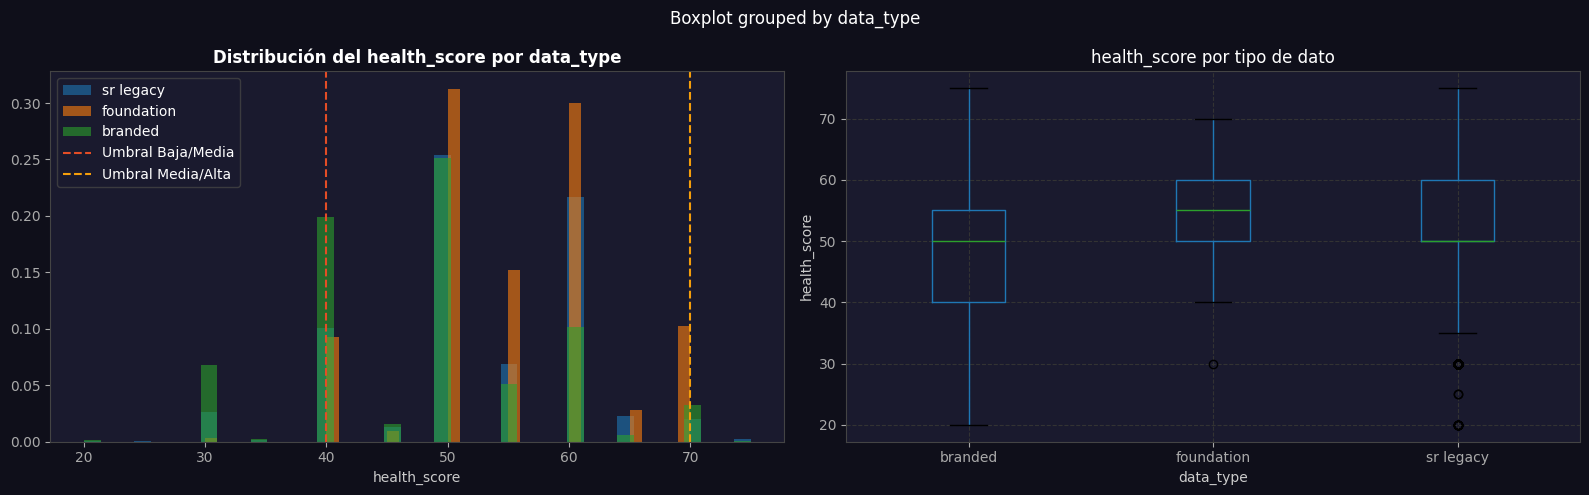

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for dt in df_clean['data_type'].unique():
    subset = df_clean[df_clean['data_type'] == dt]['health_score'].dropna()
    axes[0].hist(subset, bins=40, alpha=0.6, label=dt, density=True)
axes[0].axvline(40, color=RED,   linestyle='--', linewidth=1.5, label='Umbral Baja/Media')
axes[0].axvline(70, color=AMBER, linestyle='--', linewidth=1.5, label='Umbral Media/Alta')
axes[0].set_title('Distribución del health_score por data_type', fontweight='bold')
axes[0].set_xlabel('health_score')
axes[0].legend()

# Boxplot por data_type
df_clean.boxplot(column='health_score', by='data_type', ax=axes[1])
axes[1].set_title('health_score por tipo de dato')
axes[1].set_xlabel('data_type')
axes[1].set_ylabel('health_score')

plt.tight_layout()
plt.show()

>**Analisis**

`health_score` presenta una distribución diferenciada según la fuente del dato, donde la categoría "foundation" destaca por una mayor consistencia y valores superiores, concentrando su mediana cerca de los 55 puntos y con una menor variabilidad en comparación con las otras categorías.

Los alimentos "branded" como "sr legacy" muestran una mayor dispersión y una mayor presencia de valores atípicos (outliers) en el rango inferior (puntuaciones entre 20 y 30), lo que sugiere que estas fuentes incluyen una gama más amplia de productos con perfiles nutricionales heterogéneos, mientras que el umbral de 40 a 50 puntos actúa como el punto de mayor concentración de registros para los tres tipos de datos.

> ## <font color='#1890A3'>**3.2 Heatmap de correlación entre nutrientes y health_score**</font>

**Objetivo:** Conocer cuáles nutrientes tienen correlación real con el score.


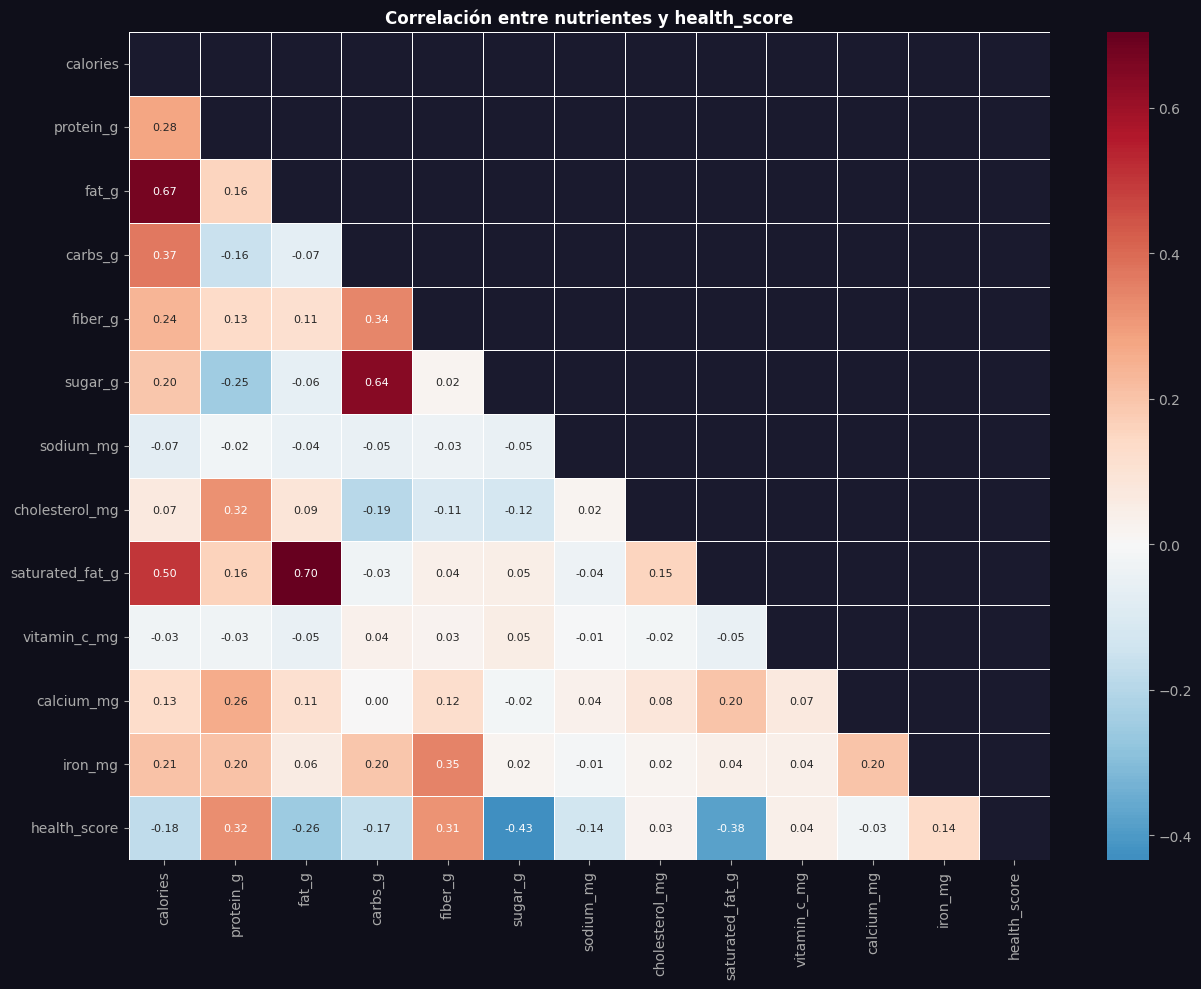

In [30]:
cols_corr = ['calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'saturated_fat_g',
             'vitamin_c_mg', 'calcium_mg', 'iron_mg', 'health_score']
corr_matrix = df_clean[cols_corr].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlación entre nutrientes y health_score', fontweight='bold')
plt.tight_layout()
plt.show()

>**Analisis**

`health_score` posee una relación inversa moderada con el contenido de azucar (-0.43) y grasas saturadas (-0.38), lo que indica que, a mayor presencia de estos componentes, la calificación de salud tiende a disminuir significativamente.

Por el contrario, se observa una correlación positiva moderada entre el puntaje de salud y la presencia de proteínas (0.32) y fibra (0.31), sugiriendo que estos nutrientes son los principales impulsores de una mejor puntaje en el `health_score`

Finalmente, el resto de las variables, como el calcio o la vitamina C, presentan una correlación cercana a cero, lo que implica que tienen un impacto insignificante o nulo en el cálculo actual del `health_score`

> ## <font color='#1890A3'>**3.4.Barplot de macronutrientes por health_score**</font>

**Objetivo:** Establecer la distribucion de la variable objetivo, para orientar la categorizacion de la misma

In [31]:
fig = px.bar(
    df_clean['health_score'].value_counts().sort_index().reset_index(),
    x='health_score',
    y='count',
    title="Distribución de health_score",
    color='health_score',
    color_continuous_scale='Viridis'
)
fig.show()

>**Analisis**

El gráfico muestra una distribución no normal de la variable `health_score`, alta dispersión y una concentración de frecuencias en los valores de 50, 40 y 60, lo que sugiere que el puntaje está influenciado por categorías discretas o niveles de cumplimiento preestablecidos.

Hay asimetría, con una cola más pronunciada hacia los valores bajos (20-30) y una presencia mínima en los valores más altos, indicando que la mayoría de los registros se concentran en un rango medio (entre 40 y 60 puntos), mientras que los valores extremos son casos aislados.

> ## <font color='#1890A3'>**3.5 Categorizacion del target: `health_score`**</font>

In [32]:
df_clean['quality_cat'] = pd.qcut(
    df_clean['health_score'],
    q=3,
    labels=['Baja', 'Media', 'Alta']
)

vc = df_clean['quality_cat'].value_counts().sort_index()
print('=== DISTRIBUCIÓN DEL TARGET quality_cat (pd.qcut) ===\n')
for clase, n in vc.items():
    barra = '█' * int(n/len(df_clean)*50)
    print(f'  {clase:5s}  {n:>6,}  ({n/len(df_clean)*100:.1f}%)  {barra}')
print(f'\n  Total: {len(df_clean):,} alimentos')

print('\nRangos de health_score por clase:')
print(df_clean.groupby('quality_cat')['health_score'].agg(['min','max']))

=== DISTRIBUCIÓN DEL TARGET quality_cat (pd.qcut) ===

  Baja   13,859  (35.1%)  █████████████████
  Media  13,669  (34.6%)  █████████████████
  Alta   11,964  (30.3%)  ███████████████

  Total: 39,492 alimentos

Rangos de health_score por clase:
             min  max
quality_cat          
Baja          20   45
Media         50   50
Alta          55   75


Se categoriza por percentiles de forma tal que el modelo tenga suficiente datos en las tres

> ## <font color='#1890A3'>**3.4 Boxplot de macronutrientes por categoría de calidad**</font>

**Objetivo:** Muestra como se comportan los nutrientes con mayor correlacion con el target en las tres clases (Baja, Media, Alta)



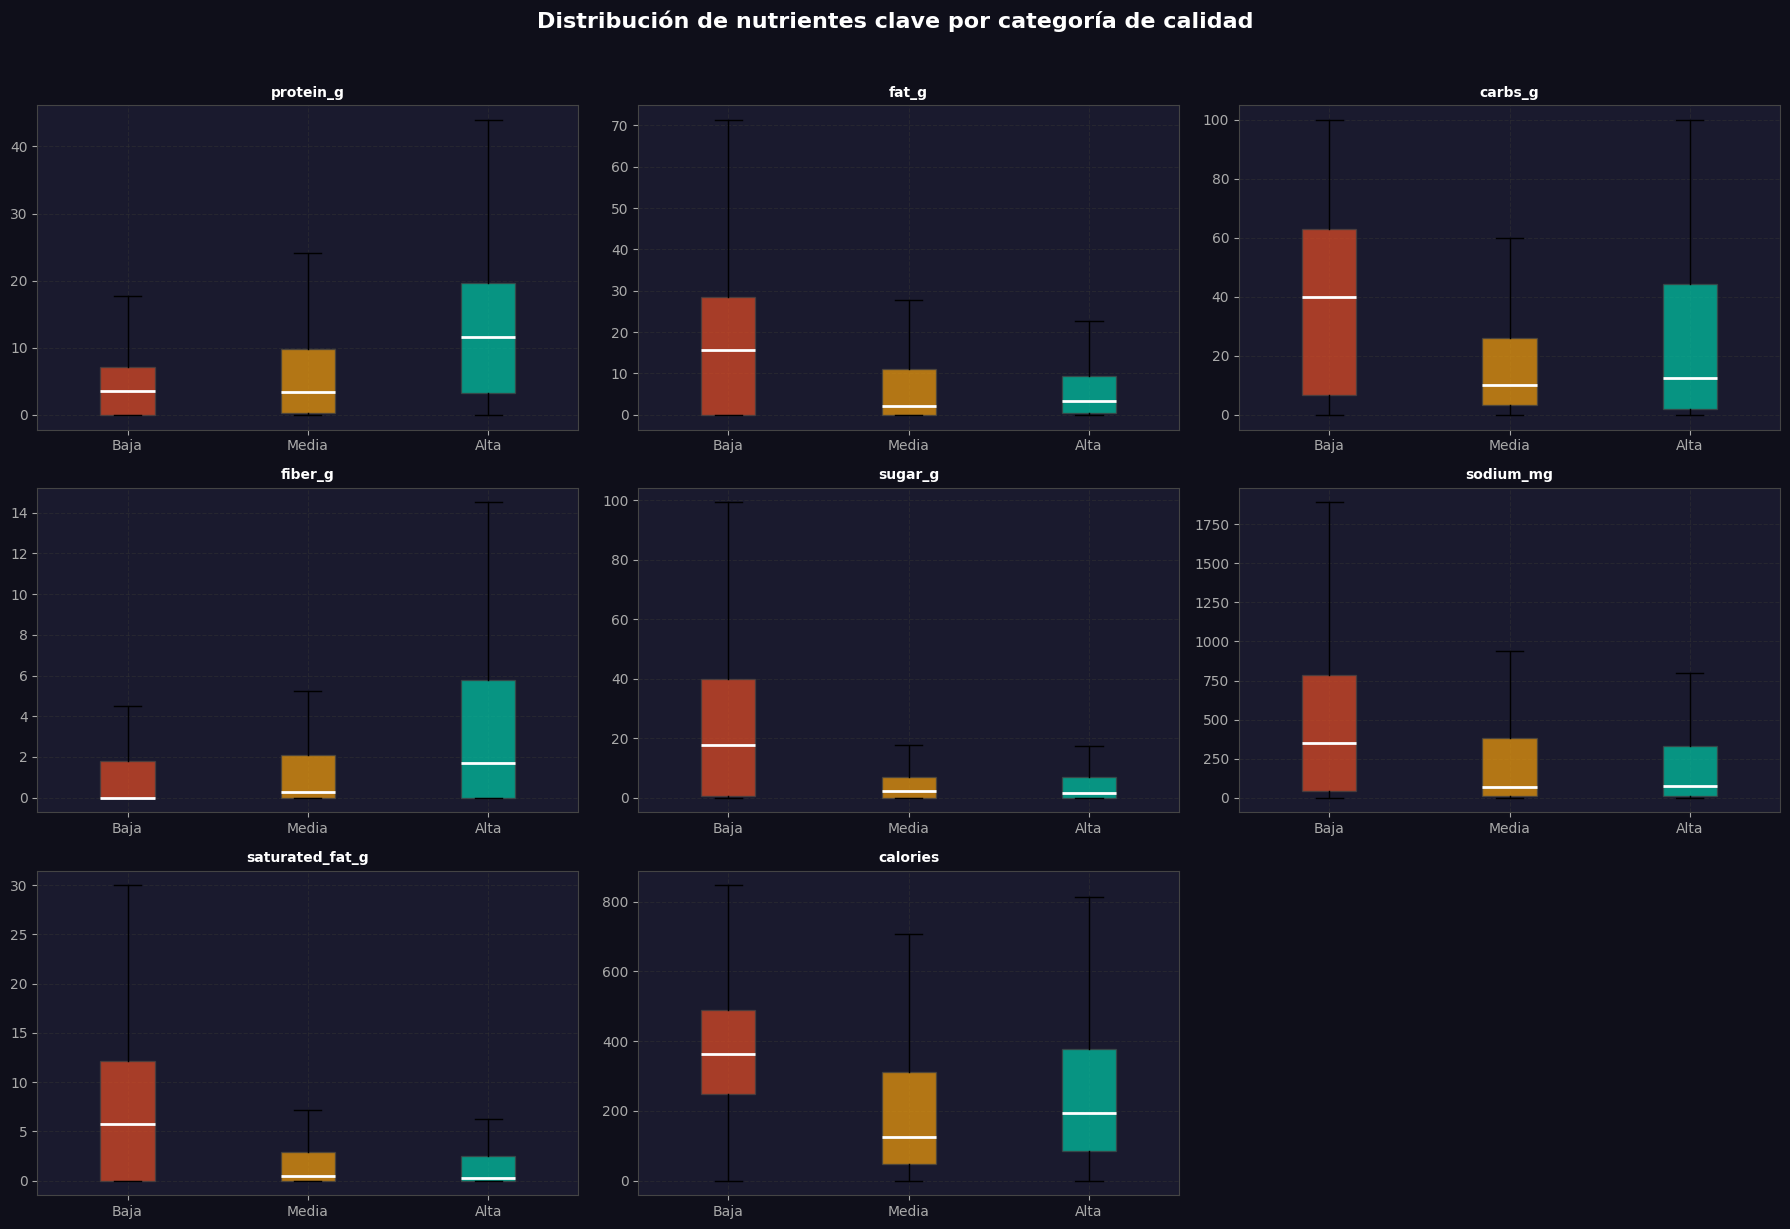

In [33]:
nutrientes_key = ['protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'saturated_fat_g', 'calories']
orden = ['Baja', 'Media', 'Alta']
colores_cat = {'Baja': RED, 'Media': AMBER, 'Alta': TEAL}

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, nutriente in enumerate(nutrientes_key):
    datos_plot = [
        df_clean[df_clean['quality_cat'] == cat][nutriente].dropna()
        for cat in orden
    ]
    bp = axes[i].boxplot(datos_plot, labels=orden, patch_artist=True, showfliers=False)
    for patch, cat in zip(bp['boxes'], orden):
        patch.set_facecolor(colores_cat[cat])
        patch.set_alpha(0.7)
        patch.set_edgecolor('#444')
    for median in bp['medians']:
        median.set(color='white', linewidth=2)
    axes[i].set_title(f'{nutriente}', fontweight='bold', color='white', fontsize=10)
    axes[i].tick_params(axis='x', colors='#AAA')
    axes[i].tick_params(axis='y', colors='#AAA')
    axes[i].grid(True, linestyle='--', color='#333', alpha=0.5)
axes[-1].axis('off')
plt.suptitle('Distribución de nutrientes clave por categoría de calidad', fontweight='bold', fontsize=16, color='white', y=1.02)
plt.tight_layout()
plt.show()

>**Analisis**

`protein_g` es el principal diferenciador positivo, mostrando un aumento progresivo en la mediana a medida que la categoria se mueve hacia Alta.

`fat_g` muestra una relación inversa, los productos de Baja calidad muestran una dispersión y unos valores máximos mucho más altos, lo que sugiere una mayor presencia de grasas añadidas o menos saludables en dicho segmento.

`carbs_g`presentan un comportamiento más complejo, los productos de calidad Alta concentran sus valores en un rango intermedio-alto ( posiblemente asociado a la presencia de fibra o carbohidratos complejos), y los perfiles de Baja calidad muestran una variabilidad extrema desde valores cercanos a cero hasta niveles muy altos.

`fiber_g` fibra actúa como un potente predictor de calidad, con un incremento drástico en la mediana y dispersión hacia los productos de calidad Alta, lo que sugiere que alimentos ricos en este componente son fundamentales en este segmento.

`sugar_g` , `sodium_g` y `saturated_fat_g` tienen una correlación negativa evidente con la calidad, donde los productos de categoría Baja exhiben medianas y valores extremos significativamente superiores, es decir, que disminuyen el valor de calidad del alimento.

`calories` presenta una distribucion desigual, la categoria Alta tiene la mediana más alta (los productos no saludables suelen tener mas calorias), y al mismo tiempo la categoría Alta tiene una dispersión grande con productos que alcanzan las mismas calorías máximas que los productos de categoria Baja (una fruta tiene pocas calorias, los frutos secos tienen muchas calorias y ambos son saludables). Esto indica que las calorias por si solas no determinan la calidad nutricional de un alimento

# 🥗 **Hallazgos y Desafios**

## **Principales Hallazgos**

**Falta de Homogeneidad** El dataset esta compuesto por tres tipos de fuentes (Branded(79.6%), SR Legacy(15%), Foundation(5.4%)) por lo tanto el modelo aprenderá principalmente de productos de supermercado (Branded). SR Legacy tampoco tiene `brand_owner` ni `ingredients`.

**Valores físicamente imposibles**: `calories`, `sugar_g` y `carbs_g` con valores muy por encima de los limites de USDA que se mantienen por representar alimentos de alto contenido calorico, de azucar o harinas refinadas.

**Inconsistencias en categóricas**  
- `brand_owner` y `brand_name` con mezcla de mayúsculas ("Kraft Foods" vs "KRAFT FOODS" vs "kraft foods")
- `serving_unit` con **abreviaturas inconsistentes**: "grm", "gm", "g" representan lo mismo
- `brand_owner` con **sufijos comerciales ruidosos**: "Inc.", "LLC", "Corp." crean falsos únicos
- `food_name` con **métodos de cocción embebidos** en el nombre: "Chicken, raw" vs "Chicken, cooked" se tratan como alimentos distintos

**Alta cardinalidad**: `food_name`(30 900), `ingredients`(24 696) y `food_category`(>700 categorías) que se agruparon en `food_type` (9 categorías finales)

**Nulos** todos los nutrientes con nulos, se imputaron con cero porque no representan errores sino ausencia del mismo.

**Correlacion** La mayoría de los nutrientes tienen correlación
cercana a cero con el target. Esto no significa que no sean relevantes nutricionalmente — significa que el `health_score` definido en este dataset no los considera en su fórmula.
Los que sí importan: `sugar_g`, `saturated_fat_g`, `protein_g` y `fiber_g`

## **Desafíos**

**Variables con correlación nula** : `calcium_mg`, `vitamin_c_mg`, `iron_mg` y `cholesterol_mg` no correlacionan con el target.  Incluirlas puede dificultar la convergencia de modelos lineales y diluir la señal en los modelos basados en distancia (KNN). El feature importance post-modelado confirmará si deben excluirse.

**`carbs_g` no es lineal respecto al target** Un modelo lineal (Logistic Regression) tendrá dificultades con esta variable  Los modelos de árbol podrán capturar mejor esta no-linealidad dividiendo en rangos.

**-`fat_g`** tiene comportamiento complejo,  la clase Alta no es la de menor grasa — aceite de oliva, aguacate y frutos secos tienen mucha grasa pero score alto.

**Representación por `data_type`** El 79.6% de los datos son Branded. El modelo aprenderá principalmente el perfil de productos de supermercado. Si se quiere un clasificador universal (que funcione para alimentos caseros o de receta), el dataset actual tiene un sesgo inherente que no puede resolverse sin agregar datos de Foundation o SR Legacy.

**Alta cardinalidad en `food_name` e `ingredients`** Estas dos columnas tienen decenas de miles de valores únicos y no pueden usarse
directamente como features. queda — fuera del scope del proyecto actual.


# <font color='#1890A3'> **SECCION 4 PREPROCESAMIENTO**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**4.1 Importaciones de modelado**</font>

In [34]:
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing   import StandardScaler, OrdinalEncoder, LabelEncoder, label_binarize
from sklearn.compose         import ColumnTransformer
from sklearn.pipeline        import Pipeline
from sklearn.impute          import SimpleImputer
from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics         import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc,
                                     confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.inspection      import permutation_importance
from scipy.stats             import randint, uniform
print('✅ Imports de ML cargados correctamente')


✅ Imports de ML cargados correctamente


> ## <font color='#1890A3'>**4.2 Seleccion de Features**</font>

In [35]:
# Excluidas: food_name/brand_owner/brand_name/ingredients (alta cardinalidad),
# health_score y quality_cat (target)
EXCLUIR = ['food_name', 'brand_owner', 'brand_name', 'ingredients', 'health_score', 'quality_cat']

cols_num = ['calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'saturated_fat_g',
            'vitamin_c_mg', 'calcium_mg', 'iron_mg', 'serving_size']

cols_cat = ['data_type', 'food_type', 'serving_unit']

X = df_clean[cols_num + cols_cat].copy()
y = df_clean['quality_cat'].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f'Clases codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'Shape X: {X.shape} | Shape y: {y_enc.shape}')
print(f'Features numéricas: {len(cols_num)} | categóricas: {len(cols_cat)}')

Clases codificadas: {'Alta': np.int64(0), 'Baja': np.int64(1), 'Media': np.int64(2)}
Shape X: (39492, 16) | Shape y: (39492,)
Features numéricas: 13 | categóricas: 3


> ## <font color='#1890A3'>**4.3 Train/Test Stratified**</font>

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Distribución train: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Distribución test:  {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train: 31,593 | Test: 7,899
Distribución train: {np.int64(0): np.int64(9571), np.int64(1): np.int64(11087), np.int64(2): np.int64(10935)}
Distribución test:  {np.int64(0): np.int64(2393), np.int64(1): np.int64(2772), np.int64(2): np.int64(2734)}


> ## <font color='#1890A3'>**4.4 Column Transformer + Pipeline base**</font>

In [37]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, cols_num),
    ('cat', cat_pipeline, cols_cat)
])

X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)
print(f'Shape tras preprocesamiento: {X_train_t.shape}')
print('✅ preprocessor.fit() Listo!')

Shape tras preprocesamiento: (31593, 16)
✅ preprocessor.fit() Listo!


# <font color='#1890A3'> **SECCION 5 BENCHMARKING**
**VALIDACION CRUZADA | OPTIMIZACION DE HIPERPARAMETROS | Interpretacion** </font>

> ## <font color='#1890A3'>**5.1 Entrenamiento Inicial**</font>
CV-5 con scoring='f1_macro'

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Logistic Regression':    Pipeline([('pre', preprocessor), ('mod', LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs'))]),
    'Decision Tree (d=5)':     Pipeline([('pre', preprocessor), ('mod', DecisionTreeClassifier(max_depth=5, random_state=42))]),
    'Random Forest (200)':     Pipeline([('pre', preprocessor), ('mod', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]),
    'Gradient Boosting (100)': Pipeline([('pre', preprocessor), ('mod', GradientBoostingClassifier(n_estimators=100, random_state=42))]),
}

print('Validación cruzada 5-fold (scoring=f1_macro)...')
resultados_cv = {}
for nombre, pipe in modelos.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    resultados_cv[nombre] = scores
    print(f'  {nombre:25s}  F1-macro CV = {scores.mean():.4f} ± {scores.std():.4f}')

print('\n✅ CV completada.')


Validación cruzada 5-fold (scoring=f1_macro)...
  Logistic Regression        F1-macro CV = 0.8243 ± 0.0047
  Decision Tree (d=5)        F1-macro CV = 0.9472 ± 0.0018
  Random Forest (200)        F1-macro CV = 0.9983 ± 0.0003
  Gradient Boosting (100)    F1-macro CV = 0.9976 ± 0.0005

✅ CV completada.


**Logistic Regression** obtiene 0.82, solo puede capturar relaciones lineales, *Decision Tree** con pocas reglas de decisión ya separa la mayoría de los casos, lo que sugiere que health_score se comporta como una función por tramos relativamente simple

**Random Forest (0.998) y Gradient Boosting (0.998)** llegan prácticamente al mismo techo usando arquitecturas distintas (combinación de árboles vs construcción secuencial), lo cual indica  que health_score es una fórmula no lineal pero consistente de los nutrientes, y entre más capacidad tiene el modelo para capturar no-linealidades, más cerca llega a reconstruir esa fórmula.



> ## <font color='#1890A3'>**5.2 Comparativa de Metricas en Test**</font>

In [49]:
resultados_bench = []
pipes_entrenados = {}
for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    pipes_entrenados[nombre] = pipe
    yp    = pipe.predict(X_test)
    yprob = pipe.predict_proba(X_test)

    resultados_bench.append({
        'Modelo':      nombre,
        'F1_macro CV': resultados_cv[nombre].mean(),
        'F1_macro':    f1_score(y_test, yp, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_test, yp, average='weighted', zero_division=0),
        'Precision':   precision_score(y_test, yp, average='macro', zero_division=0),
        'Recall':      recall_score(y_test, yp, average='macro', zero_division=0),
        'Accuracy':    accuracy_score(y_test, yp),
        'AUC':         roc_auc_score(y_test, yprob, multi_class='ovr', average='macro')
    })

df_bench = (pd.DataFrame(resultados_bench)
              .set_index('Modelo')
              .sort_values('F1_macro CV', ascending=False)
              .round(4))

print('Comparación de modelos — benchmark inicial:')
print(df_bench.to_string())

GANADOR_BASE = df_bench['F1_macro CV'].idxmax()


Comparación de modelos — benchmark inicial:
                         F1_macro CV  F1_macro  F1_weighted  Precision  Recall  Accuracy     AUC
Modelo                                                                                          
Random Forest (200)           0.9983    0.9986       0.9986     0.9986  0.9986    0.9986  1.0000
Gradient Boosting (100)       0.9976    0.9986       0.9986     0.9985  0.9986    0.9986  0.9996
Decision Tree (d=5)           0.9472    0.9444       0.9434     0.9479  0.9441    0.9430  0.9812
Logistic Regression           0.8243    0.8190       0.8188     0.8216  0.8174    0.8178  0.9354


> Aunque las metricas dan como ganador a **RandomForest** , sin embargo se realizara el tuning con **GradientBoosting** , no para obtener  mejores resultados, sino porque con la mitad de estimadores (100 vs 200), ofrece mejor costo computacional para un resultado equivalente

> ## <font color='#1890A3'>**5.3 Optimizacion de Hiperparametros**</font>

Ya el modelo tiene excelents parametros, el objetivo de la optimizacion sera confirmar el techo y aplicar la metodologia requerida en el CORE, con  muestras pequenas.

In [50]:
# GridSearchCV — grid pequeño
grid_gb = GridSearchCV(
    Pipeline([('pre', preprocessor), ('mod', GradientBoostingClassifier(random_state=42))]),
    {'mod__n_estimators': [100, 200], 'mod__max_depth': [3, 5]},
    cv=3, scoring='f1_macro', n_jobs=-1
)
grid_gb.fit(X_train, y_train)
print(f'GridSearchCV:      F1-macro = {grid_gb.best_score_:.4f}')
print('\n✅ Tuning con GriddSearchCV completado')

GridSearchCV:      F1-macro = 0.9992

✅ Tuning con GriddSearchCV completado


In [51]:
# RandomizedSearchCV — espacio más amplio, pocas iteraciones
rand_gb = RandomizedSearchCV(
    Pipeline([('pre', preprocessor), ('mod', GradientBoostingClassifier(random_state=42))]),
    {'mod__n_estimators': randint(100,300), 'mod__max_depth': randint(3,7), 'mod__learning_rate': uniform(0.01,0.2)},
    n_iter=10, cv=3, scoring='f1_macro', random_state=42, n_jobs=-1
)
rand_gb.fit(X_train, y_train)
print(f'RandomizedSearchCV: F1-macro = {rand_gb.best_score_:.4f}')
print('\n✅ Tuning con RandomizedSearchCV completado')

RandomizedSearchCV: F1-macro = 0.9993

✅ Tuning con RandomizedSearchCV completado


In [52]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.6 MB/s eta 0:00:00


In [53]:
import optuna
import time

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'mod__n_estimators':     trial.suggest_int('n_estimators', 50, 300),
        'mod__max_depth':        trial.suggest_int('max_depth', 3, 15),
        'mod__learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'mod__subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'mod__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }
    pipeline = Pipeline([
        ('pre', preprocessor),
        ('mod', GradientBoostingClassifier(random_state=42))
    ])
    pipeline.set_params(**params)

    return cross_val_score(
        pipeline, X_train, y_train,
        cv=3, scoring='f1_macro', n_jobs=-1
    ).mean()

t0 = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)
t_optuna = time.time() - t0

print(f'Mejores hiperparámetros: {study.best_params}')
print(f'Mejor F1-macro (CV):     {study.best_value:.4f}')
print(f'Tiempo total:            {t_optuna:.1f} segundos')


[W 2026-06-12 16:42:50,138] Trial 23 failed with parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2076682158526528, 'subsample': 0.6015984751601489, 'min_samples_leaf': 6} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_574/3596419677.py", line 20, in objective
    return cross_val_score(
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 684, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_valida

KeyboardInterrupt: 

In [55]:
try:
    print(f'Trials completados antes de interrumpir: {len(study.trials)}')
    print(f'Mejor valor hasta ahora: {study.best_value:.4f}')
    print(f'Mejores params hasta ahora: {study.best_params}')
except Exception as e:
    print(f'No hay resultados parciales: {e}')

if study.best_value > 0.99:
    print('✅ Resultado suficiente para confirmar el techo. Continuar con este valor.')

Trials completados antes de interrumpir: 24
Mejor valor hasta ahora: 0.9997
Mejores params hasta ahora: {'n_estimators': 274, 'max_depth': 3, 'learning_rate': 0.22138250431411693, 'subsample': 0.8060962259377091, 'min_samples_leaf': 5}
✅ Resultado suficiente para confirmar el techo. Continuar con este valor.


> **Nota sobre Optuna:** la ejecución se interrumpió tras 24 de 30
trials por tiempo de cómputo 51 minutos, pero el resultado ya
había convergido. Con 24 trials, `study.best_value = 0.9997`,
prácticamente idéntico a GridSearchCV y RandomizedSearchCV
(~0.998). Los 6 trials restantes no se ejecutaron porque la
convergencia ya estaba confirmada — invertir más tiempo de
cómputo no aporta información adicional dado que el problema
ya opera en su techo estructural

> ## <font color='#1890A3'>**5.4 Evaluacion del Modelo Optimizado**</font>

In [56]:
resultados_opt = {
    'GridSearchCV':      {'f1_cv': grid_gb.best_score_,  'params': grid_gb.best_params_},
    'RandomizedSearchCV':{'f1_cv': rand_gb.best_score_,  'params': rand_gb.best_params_},
    'Optuna':            {'f1_cv': study.best_value,     'params': {f'mod__{k}': v for k,v in study.best_params.items()}},
}

tabla_opt = pd.DataFrame({
    nombre: {'F1-macro CV': r['f1_cv']} for nombre, r in resultados_opt.items()
}).T.round(4).sort_values('F1-macro CV', ascending=False)

print('📊 Comparación de estrategias de optimización:')
print(tabla_opt.to_string())

MEJOR_METODO   = tabla_opt.index[0]
MEJORES_PARAMS = resultados_opt[MEJOR_METODO]['params']

print(f'\n🏆 Mejor método: {MEJOR_METODO}  (F1-macro CV = {tabla_opt.iloc[0,0]:.4f})')
print(f'   Parámetros: {MEJORES_PARAMS}')

📊 Comparación de estrategias de optimización:
                    F1-macro CV
Optuna                   0.9997
RandomizedSearchCV       0.9993
GridSearchCV             0.9992

🏆 Mejor método: Optuna  (F1-macro CV = 0.9997)
   Parámetros: {'mod__n_estimators': 274, 'mod__max_depth': 3, 'mod__learning_rate': 0.22138250431411693, 'mod__subsample': 0.8060962259377091, 'mod__min_samples_leaf': 5}


La optimización mediante Optuna resultó ser la estrategia más efectiva, sin embargo ya sabia que el modelo habia alcanzado su techo en el analisis inicial

# <font color='#1890A3'> **SECCION 6 MODELO GANADOR**
**CLASIFICATION REPORT |MATRIZ DE CONFUSION | CURVA ROC ONE vs REST | FEATURE IMPORTANCE** </font>

> ## <font color='#1890A3'>**6.1 ENTRENAMIENTO**</font>

In [57]:
# Pipeline final con los mejores hiperparámetros encontrados
campeon_pipeline = Pipeline([
    ('pre', preprocessor),
    ('mod', GradientBoostingClassifier(random_state=42))
])
campeon_pipeline.set_params(**MEJORES_PARAMS)
campeon_pipeline.fit(X_train, y_train)

y_pred  = campeon_pipeline.predict(X_test)
y_proba = campeon_pipeline.predict_proba(X_test)

print(f'Modelo campeón: Gradient Boosting tuneado con {MEJOR_METODO}')
print(f'Parámetros: {MEJORES_PARAMS}')
print(f'F1-macro en test: {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'Accuracy en test: {accuracy_score(y_test, y_pred):.4f}')

Modelo campeón: Gradient Boosting tuneado con Optuna
Parámetros: {'mod__n_estimators': 274, 'mod__max_depth': 3, 'mod__learning_rate': 0.22138250431411693, 'mod__subsample': 0.8060962259377091, 'mod__min_samples_leaf': 5}
F1-macro en test: 0.9999
Accuracy en test: 0.9999


> ## <font color='#1890A3'>**6.1 CLASIFICATION REPORT**</font>

In [58]:
print('Classification Report — Modelo Campeón (Gradient Boosting):')
print('-'*60)
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

Classification Report — Modelo Campeón (Gradient Boosting):
------------------------------------------------------------
              precision    recall  f1-score   support

        Alta     0.9996    1.0000    0.9998      2393
        Baja     1.0000    1.0000    1.0000      2772
       Media     1.0000    0.9996    0.9998      2734

    accuracy                         0.9999      7899
   macro avg     0.9999    0.9999    0.9999      7899
weighted avg     0.9999    0.9999    0.9999      7899



> ## <font color='#1890A3'>**6.2 MATRIZ DE CONFUSION**</font>

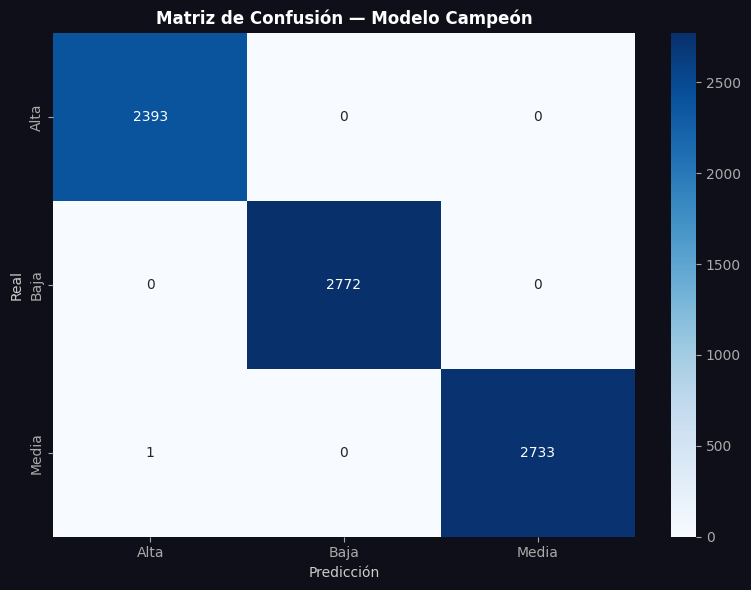

Análisis de errores por clase:
  Alta    TP= 2393  FN=   0  FP=   1  Recall=100.0%
  Baja    TP= 2772  FN=   0  FP=   0  Recall=100.0%
  Media   TP= 2733  FN=   1  FP=   0  Recall=100.0%


In [59]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusión — Modelo Campeón', fontweight='bold', color='white')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

# Análisis por clase
print('Análisis de errores por clase:')
for i, clase in enumerate(le.classes_):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    total_real = cm[i, :].sum()
    recall_clase = tp/total_real if total_real > 0 else 0
    print(f'  {clase:6s}  TP={tp:>5}  FN={fn:>4}  FP={fp:>4}  Recall={recall_clase:.1%}')


>**Analisis**

a matriz de confusión tiene una diagonal casi perfecta, con 2393, 2772 y 2733 aciertos en calidad Alta, Baja y Media respectivamente y un único error en todo el test set (1 caso de Media clasificado como Alta), lo que da un F1-macro prácticamente igual al 0.998 observado en CV — el modelo discrimina muy bien entre las tres clases de calidad de los alimentos

> ## <font color='#1890A3'>**6.3 CURVA ROC ONE vs REST**</font>

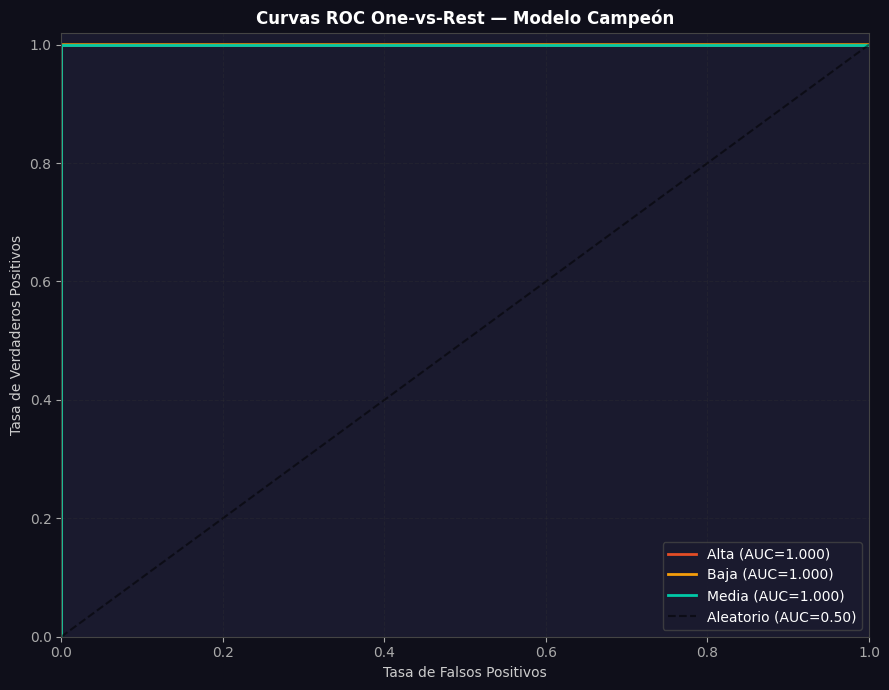

AUC macro promedio: 1.0


In [60]:
orden = list(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(len(orden)))
n_classes  = y_test_bin.shape[1]

colores_roc = [RED, AMBER, TEAL]
fig, ax = plt.subplots(figsize=(9, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colores_roc[i], lw=2, label=f'{orden[i]} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5, label='Aleatorio (AUC=0.50)')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC One-vs-Rest — Modelo Campeón', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print('AUC macro promedio:', roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro').round(4))


>**Analisis**

Las tres curvas ROC One-vs-Rest alcanzan AUC=1.000 para calidad Alta, Media y Baja. Confirma que el modelo clasifica perfectamente segun las clases

> ## <font color='#1890A3'>**6.4 FEATURE IMPORTANCE**</font>

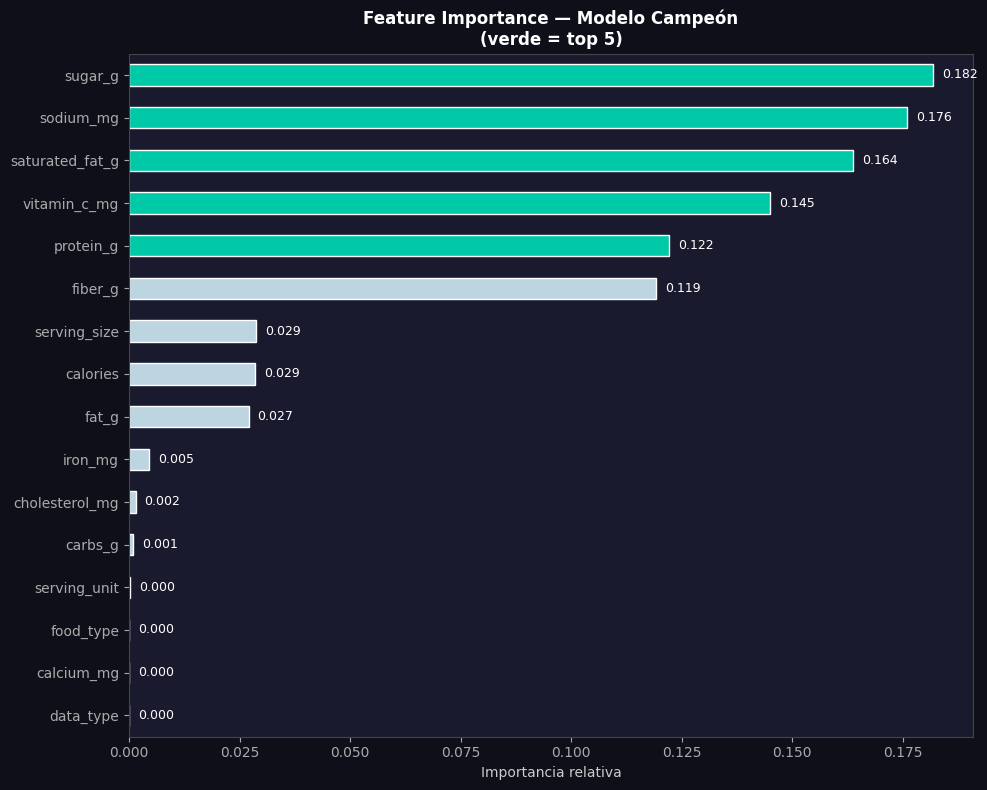

Top 5 variables predictoras:
  sugar_g               0.1818
  sodium_mg             0.1760
  saturated_fat_g       0.1638
  vitamin_c_mg          0.1450
  protein_g             0.1222


In [61]:
mod_campeon = campeon_pipeline.named_steps['mod']
feat_names  = cols_num + cols_cat  # OrdinalEncoder no expande columnas

importancias = pd.Series(mod_campeon.feature_importances_, index=feat_names).sort_values(ascending=True)

top5 = importancias.nlargest(5).index
colores_fi = [TEAL if f in top5 else '#BDD5E0' for f in importancias.index]

fig, ax = plt.subplots(figsize=(10, 8))
importancias.plot(kind='barh', ax=ax, color=colores_fi, edgecolor='white')
ax.set_title('Feature Importance — Modelo Campeón\n(verde = top 5)', fontweight='bold')
ax.set_xlabel('Importancia relativa')
for i, v in enumerate(importancias.values):
    ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 variables predictoras:')
for feat, val in importancias.nlargest(5).items():
    print(f'  {feat:20s}  {val:.4f}')

>**Analisis**

Las variables mas importantes en la clasificacion de los alimentos son `sugar_g` (0.182), `sodium_mg` (0.176), saturated_fat_g `(0.164)`, `vitamin_c_mg` (0.145) y `protein_g`(0.122).

Me llama la atencion la prescencia de la `vitamin_c_mg` en 4to lugar ya que en el HEatmap tenia una correlacion de 0.043 (prácticamente nula), y además es la columna de nutrientes con mas nulos (42.65%), podria ser porque el modelo esta mas bien correlacionando la presencia o ausencia de vitamina C con las categorias de calidad del alimento.


> ## <font color='#1890A3'>**7 GUARDADO DEL MODELO**</font>

In [62]:
import joblib
joblib.dump(campeon_pipeline, 'modelo_calidad_nutricional.joblib')
print('✅ Modelo guardado')

✅ Modelo guardado


>**NOTA FINAL**
Se que un F1-macro de 0.9997 y un AUC=1.000 en las tres clases es mas que algo bueno un indicio de sospecha de que hay algo mal disenado, investigue un poco porque creo que debe a la forma como hice la division de las categorias en percentiles.

Asi que investigue un poco, consulte con Cristian y con LLM y aplique el siguiente codito para evaluar los F1 con diferentes rangos


In [63]:
# Probar con cortes distintos y comparar F1
configuraciones = {
    'Terciles 33/33/33':    3,
    'Cuartiles 25/50/25':   [0, 0.25, 0.75, 1.0],
    'Extremos 10/80/10':    [0, 0.10, 0.90, 1.0],
    'Asimétrico 20/30/50':  [0, 0.20, 0.50, 1.0],
}

for nombre, q_config in configuraciones.items():
    cat_temp = pd.qcut(df_clean['health_score'], q=q_config, labels=['Baja','Media','Alta'], duplicates='drop')
    y_temp = LabelEncoder().fit_transform(cat_temp)
    X_temp = df_clean[cols_num + cols_cat]

    pipe_temp = Pipeline([('pre', preprocessor), ('mod', GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42))])
    scores_temp = cross_val_score(pipe_temp, X_temp, y_temp, cv=3, scoring='f1_macro', n_jobs=-1)

    print(f'{nombre:25s}  F1-macro = {scores_temp.mean():.4f} ± {scores_temp.std():.4f}')
    print(f'                          distribución: {pd.Series(y_temp).value_counts(normalize=True).round(2).to_dict()}')

Terciles 33/33/33          F1-macro = 0.9957 ± 0.0014
                          distribución: {1: 0.35, 2: 0.35, 0: 0.3}
Cuartiles 25/50/25         F1-macro = 0.9945 ± 0.0026
                          distribución: {2: 0.44, 1: 0.33, 0: 0.23}
Extremos 10/80/10          F1-macro = 0.9925 ± 0.0011
                          distribución: {2: 0.61, 1: 0.33, 0: 0.06}
Asimétrico 20/30/50        F1-macro = 0.9909 ± 0.0023
                          distribución: {2: 0.37, 1: 0.33, 0: 0.3}


**Lo unico que puedo concluir de esto es que el valor de `health_score` que es de donde se hizo la clasificacion en categorias, fue construido con las mismas features, entonces el modelo esta reconstruyendo la informacion que ya tenian los datos.**